In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import numpy as np

def dtqw_step(circuit, coin_qubit, position_qubits):
    # Hadamard coin on coin qubit
    circuit.h(coin_qubit)
    
    # Conditional shift: if coin = |0>, decrement position
    # if coin = |1>, increment position
    # This requires controlled add/subtract circuits
    # Simplified: use controlled-X with position qubits
    
    # Decrement when coin = |0>
    circuit.cx(coin_qubit, position_qubits[0])  # Simplified example
    
    # Increment when coin = |1> (using X then CX then X)
    circuit.x(coin_qubit)
    circuit.cx(coin_qubit, position_qubits[0])
    circuit.x(coin_qubit)



In [11]:
# Build circuit for 2 coin steps
coin = QuantumRegister(1, 'coin')
position = QuantumRegister(2, 'Q')
classical = ClassicalRegister(2, 'meas')
qc = QuantumCircuit(coin, position, classical)

#qc.draw('mpl')

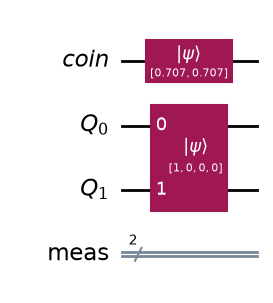

In [12]:
# Initialise qubits
qc.initialize([1/np.sqrt(2), 1/np.sqrt(2)], coin)
qc.initialize([1, 0, 0, 0], position)
qc.draw('mpl')

In [13]:
for step in range(10):
    dtqw_step(qc, coin[0], position)

# Measure position qubits
qc.measure(position, classical)

# Simulate
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

In [24]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.visualization import plot_histogram

# Define increment operator circuit
inc_c = QuantumCircuit(2, name="Increment operator")
inc_c.cx(0, 1)
inc_c.x(0)

# Convert the circuit to a controlled gate
c_inc_gate = inc_c.to_gate().control(1)
    
# Define decrement circuit
dec_c = QuantumCircuit(2, name="Decrement operator")
dec_c.x(0)
dec_c.cx(0, 1)

# Convert decrease circuit to a controlled gate
c_dec_gate = dec_c.to_gate().control(1)


# Define circuit for one step of DTQW
def dtqw_step(qc, position, coin):
    qc.h(coin)
    qc.x(coin)
    qc.append(c_dec_gate, [coin, position[0], position[1]])
    qc.x(coin)
    qc.append(c_inc_gate, [coin, position[0], position[1]])
    qc.x(coin)


# Initialise registers for walk
nodes = QuantumRegister(2, "position")
coin = QuantumRegister(1, "coin")
classical = ClassicalRegister(2, "measurement")

"""
qc_1 = QuantumCircuit(nodes)
qc_1.initialize([1, 0, 0, 0], nodes)

state = Statevector.from_instruction(qc_1)
print(state)
"""


'\nqc_1 = QuantumCircuit(nodes)\nqc_1.initialize([1, 0, 0, 0], nodes)\n\nstate = Statevector.from_instruction(qc_1)\nprint(state)\n'

{'00': 515, '10': 485} 





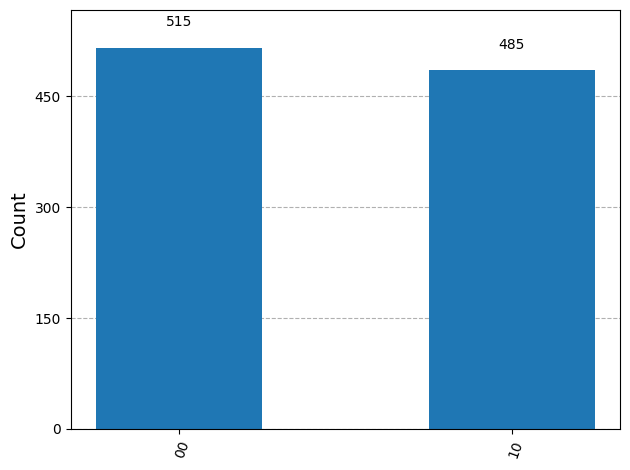

In [ ]:
# Initialise quantum circuit
qc = QuantumCircuit(coin, nodes, classical)
qc.initialize([1, 0], coin)
qc.initialize([1, 0, 0, 0], nodes)

# print(nodes[0], "\n", x[1])
qc.draw('mpl', reverse_bits=True)

# Set number of steps of walk
n_steps = 2

# Create circuit for a given number of steps of DTQW
for _ in range(n_steps):
    dtqw_step(qc, nodes, coin)

# Measure position qubits
qc.measure(nodes, classical)

# Simulate walk
simulator = AerSimulator()
qct = transpile(qc, simulator)
result = simulator.run(qct, shots=1000).result()
counts = result.get_counts()

print(counts, "\n"*3)

# Visualise measurement outcomes
plot_histogram(counts)

